In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    silhouette_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("ecommerce_customer_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.rename(columns={
    "Purchase Amount (USD)": "Price",
    "Review Rating": "Rating",
    "Previous Purchases": "Previous_Purchases",
    "Discount Applied": "Discount_Applied",
    "Subscription Status": "Subscription_Status",
    "Promo Code Used": "Promo_Code_Used",
})
df.columns = [c.replace(" ", "_") for c in df.columns]
df.head()

Missing values:
 0
Duplicate rows: 0


,Customer_ID,Age,Gender,Item_Purchased,Category,Price,Location,Size,Color,Season,Rating,Subscription_Status,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
binary_cols = ["Discount_Applied", "Promo_Code_Used", "Subscription_Status"]
for c in binary_cols:
    df[c + "_flag"] = df[c].map({"Yes": 1, "No": 0})

df["Gender_flag"] = df["Gender"].map({"Male": 1, "Female": 0})

df[["Discount_Applied", "Discount_Applied_flag", "Subscription_Status",
    "Subscription_Status_flag", "Gender", "Gender_flag"]].head()

,Discount_Applied,Discount_Applied_flag,Subscription_Status,Subscription_Status_flag,Gender,Gender_flag
0,Yes,1,Yes,1,Male,1
1,Yes,1,Yes,1,Male,1
2,Yes,1,Yes,1,Male,1
3,Yes,1,Yes,1,Male,1
4,Yes,1,Yes,1,Male,1


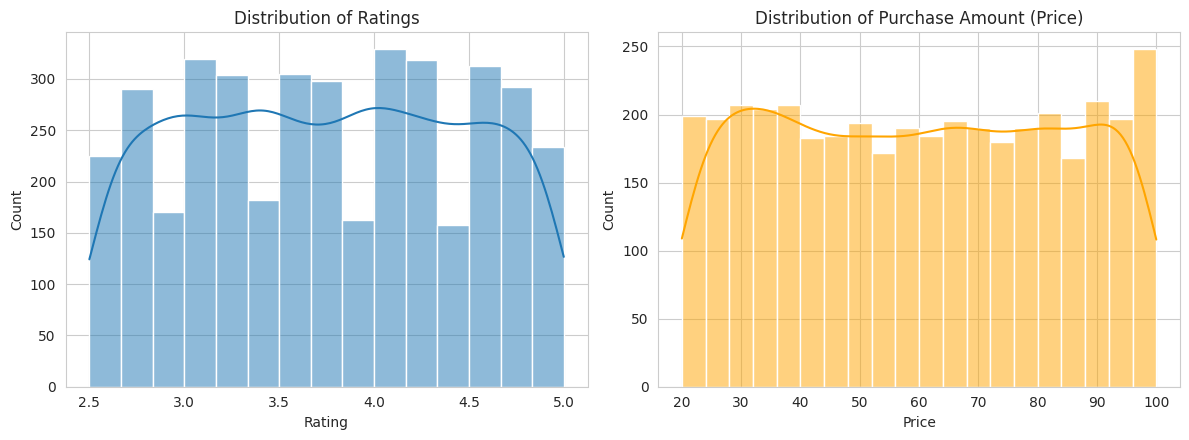

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Rating"], bins=15, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Ratings")
sns.histplot(df["Price"], bins=20, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Purchase Amount (Price)")
plt.tight_layout()
plt.show()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


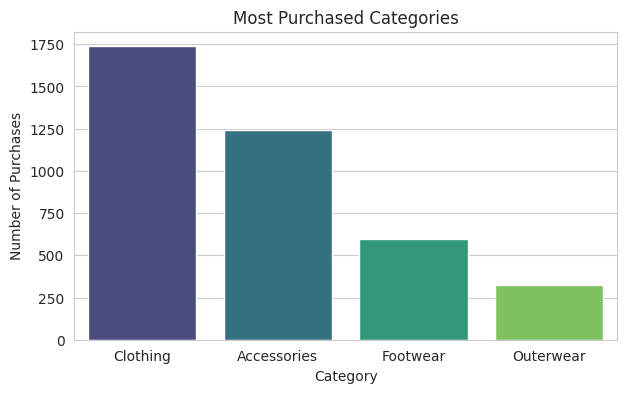

In [8]:
top_categories = df["Category"].value_counts()
print(top_categories)

plt.figure(figsize=(7,4))
sns.barplot(x=top_categories.index, y=top_categories.values, hue=top_categories.index,
            palette="viridis", legend=False)
plt.title("Most Purchased Categories")
plt.ylabel("Number of Purchases")
plt.show()

Category
Footwear       3.790651
Accessories    3.768629
Outerwear      3.746914
Clothing       3.723143
Name: Rating, dtype: float64


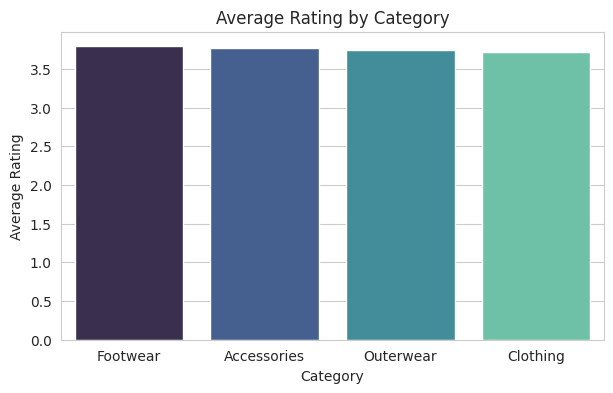

In [9]:
avg_rating_by_cat = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print(avg_rating_by_cat)

plt.figure(figsize=(7,4))
sns.barplot(x=avg_rating_by_cat.index, y=avg_rating_by_cat.values, hue=avg_rating_by_cat.index,
            palette="mako", legend=False)
plt.title("Average Rating by Category")
plt.ylabel("Average Rating")
plt.show()

Subscription rate by discount usage:
 Discount_Applied
No     0.000000
Yes    0.627907
Name: Subscription_Status_flag, dtype: float64


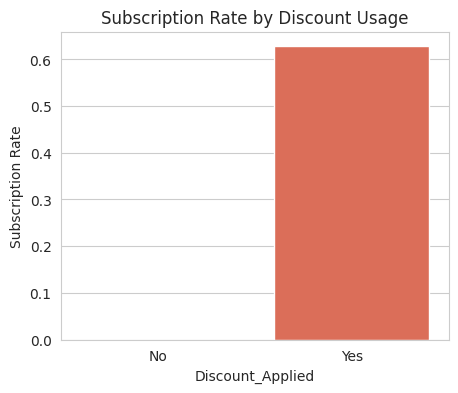

In [10]:
discount_rate = df.groupby("Discount_Applied")["Subscription_Status_flag"].mean()
print("Subscription rate by discount usage:\n", discount_rate)

plt.figure(figsize=(5,4))
sns.barplot(x=discount_rate.index, y=discount_rate.values, hue=discount_rate.index,
            palette="rocket", legend=False)
plt.title("Subscription Rate by Discount Usage")
plt.ylabel("Subscription Rate")
plt.show()

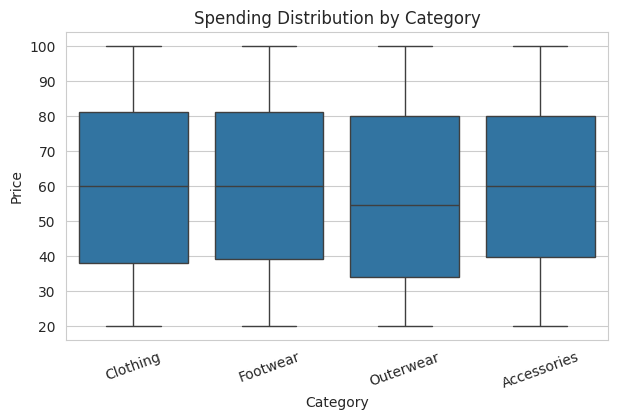

In [11]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Category", y="Price")
plt.title("Spending Distribution by Category")
plt.xticks(rotation=20)
plt.show()

In [12]:
reg_features_num = ["Price", "Previous_Purchases", "Discount_Applied_flag", "Age", "Promo_Code_Used_flag"]
reg_cat = pd.get_dummies(df["Category"], prefix="Cat", drop_first=True)

X_reg = pd.concat([df[reg_features_num], reg_cat], axis=1)
y_reg = df["Rating"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
X_train_r_scaled = scaler_reg.fit_transform(X_train_r)
X_test_r_scaled = scaler_reg.transform(X_test_r)

ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_r_scaled, y_train_r)
y_pred_r = ridge.predict(X_test_r_scaled)

mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 : {r2:.4f}")

MAE : 0.6465
MSE : 0.5451
RMSE: 0.7383
R^2 : 0.0004


In [13]:
clf_features = ["Price", "Previous_Purchases", "Rating", "Discount_Applied_flag",
                "Promo_Code_Used_flag", "Age"]
X_clf = df[clf_features]
y_clf = df["Subscription_Status_flag"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_c_scaled = scaler_clf.fit_transform(X_train_c)
X_test_c_scaled = scaler_clf.transform(X_test_c)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_c_scaled, y_train_c)

y_pred_c = logreg.predict(X_test_c_scaled)
y_proba_c = logreg.predict_proba(X_test_c_scaled)[:, 1]

acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
roc_auc = roc_auc_score(y_test_c, y_proba_c)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8641
Precision: 0.6656
Recall   : 1.0000
F1-score : 0.7992
ROC-AUC  : 0.9004


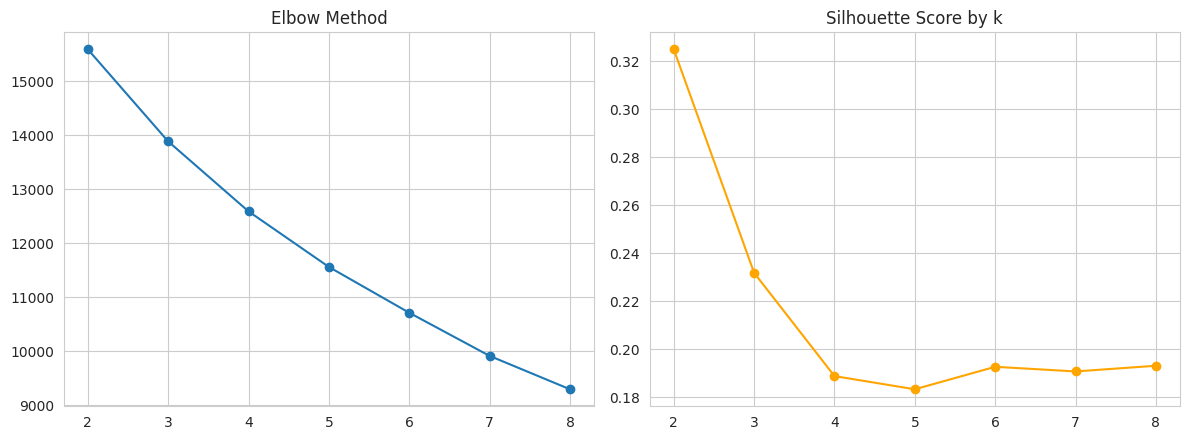

Chosen k: 2


,Price,Previous_Purchases,Rating,Age,Discount_Applied_flag,Promo_Code_Used_flag,Count
Cluster,,,,,,,
0,59.28,25.74,3.74,44.14,1.0,1.0,1677
1,60.13,25.06,3.76,44.01,0.0,0.0,2223


In [14]:
cluster_features = ["Price", "Previous_Purchases", "Rating", "Age",
                    "Discount_Applied_flag", "Promo_Code_Used_flag"]
X_cluster = df[cluster_features]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inertias = []
sil_scores = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[1].plot(list(k_range), sil_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score by k")
plt.tight_layout()
plt.show()

best_k = k_range[int(np.argmax(sil_scores))]
print("Chosen k:", best_k)

kmeans_final = KMeans(n_clusters=best_k, init="k-means++", random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

cluster_profile = df.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile["Count"] = df["Cluster"].value_counts().sort_index()
cluster_profile

In [15]:
ridge_grid = {"alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
ridge_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid,
                             scoring="neg_mean_absolute_error", cv=5)
ridge_search.fit(X_train_r_scaled, y_train_r)

best_ridge = ridge_search.best_estimator_
y_pred_r_tuned = best_ridge.predict(X_test_r_scaled)

print("Best alpha:", ridge_search.best_params_)
print("Tuned MAE :", mean_absolute_error(y_test_r, y_pred_r_tuned))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_r_tuned)))
print("Tuned R^2 :", r2_score(y_test_r, y_pred_r_tuned))

Best alpha: {'alpha': 100.0}
Tuned MAE : 0.6464888904425404
Tuned RMSE: 0.738251824351487
Tuned R^2 : 0.00044892240920690885


In [16]:
logreg_grid = [
    {"penalty": ["l2"], "C": [0.01, 0.1, 1, 10], "solver": ["lbfgs"], "max_iter": [1000]},
    {"penalty": ["l1"], "C": [0.01, 0.1, 1, 10], "solver": ["liblinear"], "max_iter": [1000]},
]
logreg_search = GridSearchCV(LogisticRegression(random_state=RANDOM_STATE), logreg_grid,
                              scoring="f1", cv=5)
logreg_search.fit(X_train_c_scaled, y_train_c)

best_logreg = logreg_search.best_estimator_
y_pred_c_tuned = best_logreg.predict(X_test_c_scaled)
y_proba_c_tuned = best_logreg.predict_proba(X_test_c_scaled)[:, 1]

print("Best params:", logreg_search.best_params_)
print("Tuned Accuracy :", accuracy_score(y_test_c, y_pred_c_tuned))
print("Tuned F1-score :", f1_score(y_test_c, y_pred_c_tuned))
print("Tuned ROC-AUC  :", roc_auc_score(y_test_c, y_proba_c_tuned))

Best params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Tuned Accuracy : 0.8641025641025641
Tuned F1-score : 0.7992424242424242
Tuned ROC-AUC  : 0.9005905429830333


In [17]:
comparison = pd.DataFrame({
    "Model": ["Ridge Regression (tuned)", "Logistic Regression (tuned)", f"K-Means (k={best_k})"],
    "ML Task": ["Rating prediction", "Conversion/purchase-likelihood prediction", "Customer segmentation"],
    "Key Metric 1": [f"MAE={mean_absolute_error(y_test_r, y_pred_r_tuned):.3f}",
                      f"F1={f1_score(y_test_c, y_pred_c_tuned):.3f}",
                      f"Silhouette={max(sil_scores):.3f}"],
    "Key Metric 2": [f"R2={r2_score(y_test_r, y_pred_r_tuned):.3f}",
                      f"ROC-AUC={roc_auc_score(y_test_c, y_proba_c_tuned):.3f}",
                      f"Inertia={kmeans_final.inertia_:.1f}"],
    "Business Value": [
        "Flags which products a customer is likely to rate highly",
        "Flags which customers are likely to convert/subscribe",
        "Groups customers for targeted marketing"
    ]
})
comparison

,Model,ML Task,Key Metric 1,Key Metric 2,Business Value
0,Ridge Regression (tuned),Rating prediction,MAE=0.646,R2=0.000,Flags which products a customer is likely to r...
1,Logistic Regression (tuned),Conversion/purchase-likelihood prediction,F1=0.799,ROC-AUC=0.901,Flags which customers are likely to convert/su...
2,K-Means (k=2),Customer segmentation,Silhouette=0.325,Inertia=15595.9,Groups customers for targeted marketing
